# **Lead Conversion Prediction using Machine Learning**
---
| | |
|---|---|
| **Company** | Knovista Technologies Pvt Ltd |
| **Author** | Abel Dani Stanly |
| **Role** | Data Analytics and ML Intern |
| **Dataset** | Unified_Leads.csv — 27,375 real CRM records |
| **Problem** | Predict whether a lead will convert into a paying customer |
| **Type** | Binary Classification — CONVERTED = 1, LOST = 0 |

**Algorithms:** KNN · Naive Bayes · SVM · Decision Tree · Random Forest

---
## **Step 1 — Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.svm             import SVC
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## **Step 2 — Loading the Dataset**

In [2]:
df = pd.read_csv('Unified_Leads.csv')
df.head()

,Name,contact_number,Contact_email,creation_date,first_call_attempt,lead_status,lead_stage,lead_tag,assigned_to,last_call_date,last_call_time,references,campaign_name,source_type,source_name
0,Anjali Singh,9931980478,anjali.singh878@hotmail.com,03-02-26 22:31,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
1,Kiran Bose,6474315136,kiran.bose601@example.com,03-02-26 21:46,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,FACEBOOK_ADS,FACEBOOK_ADS
2,Karthik Malhotra,6753707898,karthik.malhotra329@example.com,03-02-26 21:28,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
3,Anjali Sharma,9439163624,anjali.sharma85@example.com,03-02-26 19:59,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM
4,Sneha Kapoor,9878269840,sneha.kapoor46@gmail.com,03-02-26 19:19,NaN,PENDING WITH EXECUTIVE,Prospect,NaN,Anshad,NaN,NaN,NaN,Data Analytics Knovista,INSTAGRAM,INSTAGRAM


---
## **Step 3 — Understanding the Data**

In [3]:
print('Shape:', df.shape)
print('Size :', df.size)

Shape: (27375, 15)
Size : 410625


In [4]:
print('Missing Values:')
print(df.isna().sum())

Missing Values:
Name                      0
contact_number            0
Contact_email             0
creation_date             0
first_call_attempt     6729
lead_status               0
lead_stage                0
lead_tag              11416
assigned_to               0
last_call_date         6729
last_call_time         6729
references            27375
campaign_name             0
source_type               0
source_name               0
dtype: int64


In [5]:
print(df.dtypes)

Name                   object
contact_number          int64
Contact_email          object
creation_date          object
first_call_attempt     object
lead_status            object
lead_stage             object
lead_tag               object
assigned_to            object
last_call_date         object
last_call_time         object
references            float64
campaign_name          object
source_type            object
source_name            object
dtype: object


In [6]:
print('Target Column — lead_stage:')
print(df['lead_stage'].value_counts())

Target Column — lead_stage:
lead_stage
LOST                  11698
Prospect              10119
Follow Up Required     4713
CONVERTED               845
Name: count, dtype: int64


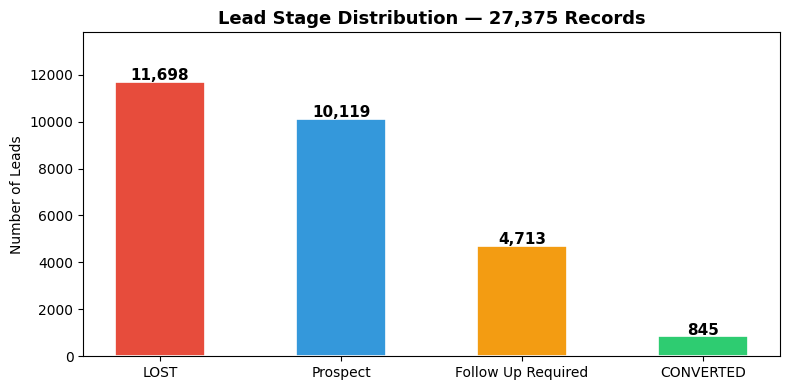

In [7]:
counts = df['lead_stage'].value_counts()
plt.figure(figsize=(8, 4))
bars = plt.bar(counts.index, counts.values,color=['#e74c3c','#3498db','#f39c12','#2ecc71'],edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,f'{val:,}', ha='center', fontweight='bold', fontsize=11)
plt.title('Lead Stage Distribution — 27,375 Records', fontsize=13, fontweight='bold')
plt.ylabel('Number of Leads')
plt.ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()

---
## **Step 4 — Exploratory Data Analysis (EDA)**

**Understanding which factors drive lead conversion before building any model.**

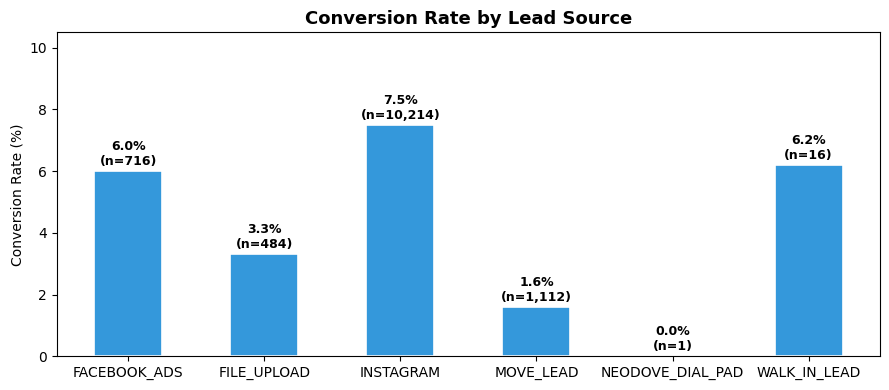

Observation: Instagram has the highest conversion rate among all lead sources in the dataset.


In [8]:
# Filter to definitive outcomes for EDA charts
df_eda = df[df['lead_stage'].isin(['CONVERTED','LOST'])].copy()
df_eda['assigned_to'] = df_eda['assigned_to'].str.strip()
df_eda['converted'] = (df_eda['lead_stage'] == 'CONVERTED').astype(int)

# EDA 1 — Conversion Rate by Lead Source
source_cr = (df_eda.groupby('source_type')['converted'].mean() * 100).round(1)
source_n  =  df_eda.groupby('source_type')['converted'].count()

plt.figure(figsize=(9, 4))
bars = plt.bar(source_cr.index, source_cr.values,color='#3498db', edgecolor='white', linewidth=1.2, width=0.5)
for bar, (src, val) in zip(bars, source_cr.items()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val}%\n(n={source_n[src]:,})', ha='center', fontsize=9, fontweight='bold')
plt.title('Conversion Rate by Lead Source', fontsize=13, fontweight='bold')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, source_cr.max() * 1.4)
plt.tight_layout()
plt.show()
print('Observation: Instagram has the highest conversion rate among all lead sources in the dataset.')

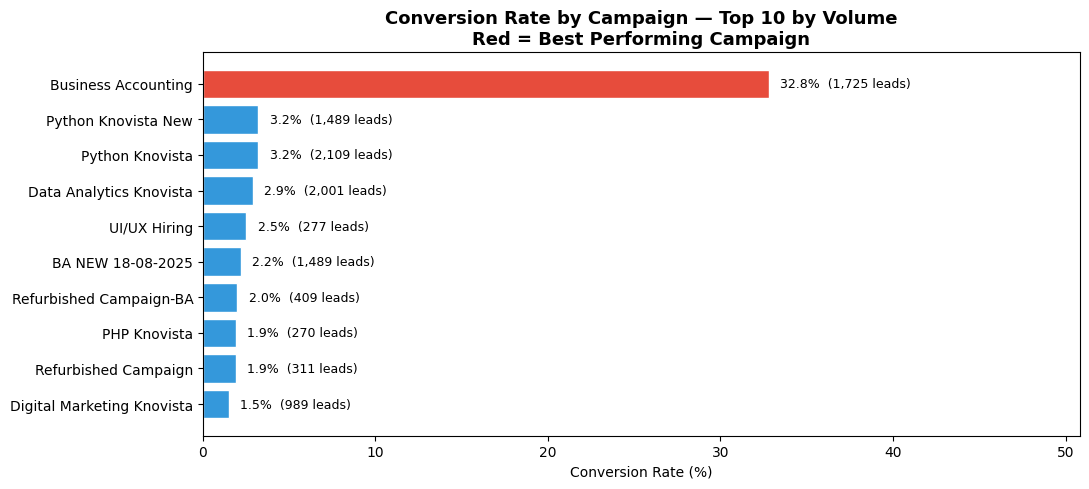

Observation: Business Accounting has the highest conversion rate among the top campaigns (~33%)


In [9]:
# EDA 2 — Conversion Rate by Campaign (Top 10 by volume)
camp_stats = df_eda.groupby('campaign_name')['converted'].agg(['mean','count']).reset_index()
camp_stats.columns = ['Campaign', 'Conv_Rate', 'Total']
camp_stats['Conv_Pct'] = (camp_stats['Conv_Rate'] * 100).round(1)
top10 = camp_stats.nlargest(10, 'Total').sort_values('Conv_Pct', ascending=True)

colors = ['#e74c3c' if x > 15 else '#3498db' for x in top10['Conv_Pct']]
plt.figure(figsize=(11, 5))
bars = plt.barh(top10['Campaign'], top10['Conv_Pct'], color=colors, edgecolor='white')
for bar, (_, row) in zip(bars, top10.iterrows()):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f"  {row['Conv_Pct']}%  ({int(row['Total']):,} leads)", va='center', fontsize=9)
plt.xlabel('Conversion Rate (%)')
plt.title('Conversion Rate by Campaign — Top 10 by Volume\nRed = Best Performing Campaign',fontsize=13, fontweight='bold')
plt.xlim(0, top10['Conv_Pct'].max() * 1.55)
plt.tight_layout()
plt.show()
print('Observation: Business Accounting has the highest conversion rate among the top campaigns (~33%)')

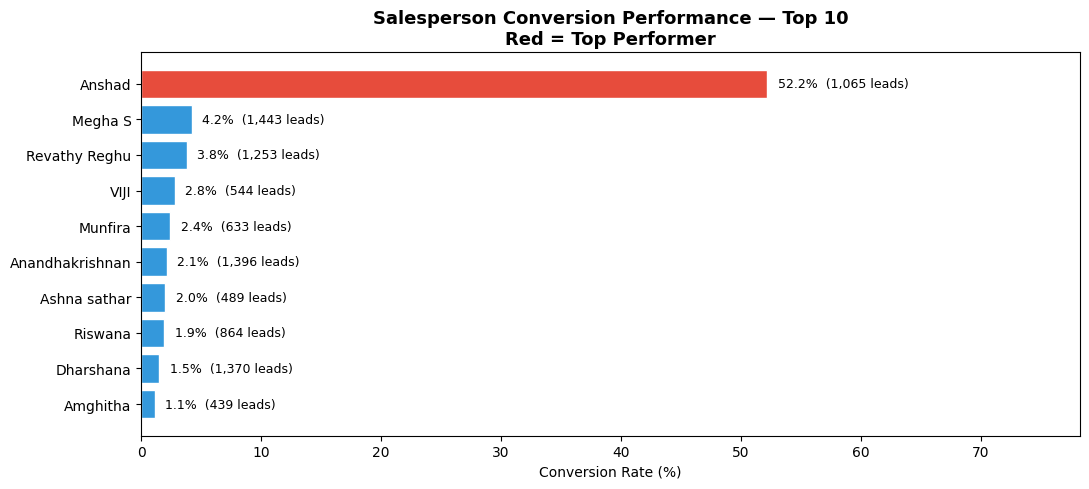

Observation: The top-performing salesperson achieves a substantially higher conversion rate than the overall dataset average, indicating strong differences in sales performance.


In [10]:
# EDA 3 — Salesperson Performance
agent_stats = df_eda.groupby('assigned_to')['converted'].agg(['mean','count']).reset_index()
agent_stats.columns = ['Salesperson', 'Conv_Rate', 'Total']
agent_stats['Conv_Pct'] = (agent_stats['Conv_Rate'] * 100).round(1)
top_agents = agent_stats.nlargest(10, 'Total').sort_values('Conv_Pct', ascending=True)

colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
          for x in top_agents['Conv_Pct']]
plt.figure(figsize=(11, 5))
bars = plt.barh(top_agents['Salesperson'], top_agents['Conv_Pct'],color=colors, edgecolor='white')
for bar, (_, row) in zip(bars, top_agents.iterrows()):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f"  {row['Conv_Pct']}%  ({int(row['Total']):,} leads)", va='center', fontsize=9)
plt.xlabel('Conversion Rate (%)')
plt.title('Salesperson Conversion Performance — Top 10\nRed = Top Performer',fontsize=13, fontweight='bold')
plt.xlim(0, top_agents['Conv_Pct'].max() * 1.5)
plt.tight_layout()
plt.show()
print('Observation: The top-performing salesperson achieves a substantially higher conversion rate than the overall dataset average, indicating strong differences in sales performance.')

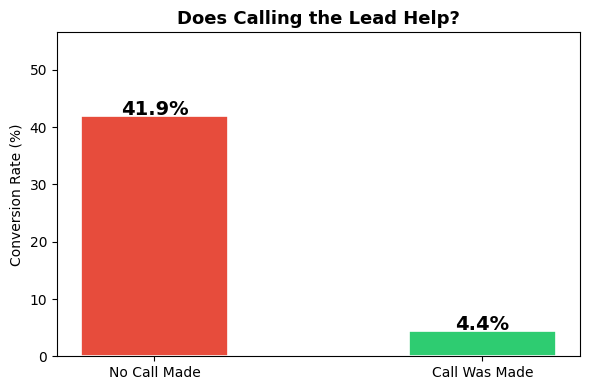

Observation: Leads without a recorded call show a higher conversion rate. This represents a correlation and should not be interpreted as evidence that making calls reduces conversions.


In [11]:
# EDA 4 — Does Making a Call Help?
df_eda['had_call'] = df_eda['first_call_attempt'].notna().astype(int)
call_cr = (df_eda.groupby('had_call')['converted'].mean() * 100).round(1)

plt.figure(figsize=(6, 4))
bars = plt.bar(['No Call Made', 'Call Was Made'], call_cr.values,color=['#e74c3c','#2ecc71'], edgecolor='white', linewidth=1.2, width=0.45)
for bar, val in zip(bars, call_cr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val}%', ha='center', fontsize=14, fontweight='bold')
plt.ylabel('Conversion Rate (%)')
plt.title('Does Calling the Lead Help?', fontsize=13, fontweight='bold')
plt.ylim(0, call_cr.max() * 1.35)
plt.tight_layout()
plt.show()
print('Observation: Leads without a recorded call show a higher conversion rate. This represents a correlation and should not be interpreted as evidence that making calls reduces conversions.')

**Observation:**

**The higher conversion rate for leads without a recorded call does not necessarily mean that making calls reduces conversions. It is likely that many self-motivated leads converted without requiring a follow-up call.**

---
## **Step 5 — Data Preprocessing**

**Columns removed and why:**

| Column | Reason |
|--------|--------|
| Name, contact_number, Contact_email | Private info — not useful for prediction |
| references | 100% empty column |
| lead_status, lead_tag, source_name | Set AFTER outcome is known — data leakage |
| creation_date, last_call_date, last_call_time | Complex date columns not needed |

**New column created:** `had_call_attempt` — 1 if a call was made, 0 if not

In [12]:
df_model = df.copy()

# Drop columns we do not need
df_model = df_model.drop(columns=['Name', 'contact_number', 'Contact_email', 'references', 'lead_status', 'lead_tag',
                                   'source_name', 'creation_date','last_call_date', 'last_call_time'])

# Strip whitespace from text columns to avoid encoding errors
df_model['assigned_to']  = df_model['assigned_to'].str.strip()
df_model['campaign_name'] = df_model['campaign_name'].str.strip()
df_model['source_type']   = df_model['source_type'].str.strip()

# Create had_call_attempt — 1 if call was made, 0 if not
df_model['had_call_attempt'] = df_model['first_call_attempt'].notna().astype(int)
df_model = df_model.drop(columns=['first_call_attempt'])

# Keep only leads with a definitive outcome
df_model = df_model[df_model['lead_stage'].isin(['CONVERTED', 'LOST'])]

# Create Target Column — CONVERTED = 1, LOST = 0
df_model['target'] = df_model['lead_stage'].map({'CONVERTED': 1, 'LOST': 0})
df_model = df_model.drop(columns=['lead_stage'])
df_model = df_model.reset_index(drop=True)

print('Shape after preprocessing:', df_model.shape)
print()
print('Target column:')
print(df_model['target'].value_counts())
print()
df_model.head()

Shape after preprocessing: (12543, 5)

Target column:
target
0    11698
1      845
Name: count, dtype: int64



,assigned_to,campaign_name,source_type,had_call_attempt,target
0,Dharshana,Data Analytics Knovista,INSTAGRAM,1,0
1,Megha S,Data Analytics Knovista,FACEBOOK_ADS,1,0
2,Revathy Reghu,Data Analytics Knovista,INSTAGRAM,1,0
3,Megha S,Data Analytics Knovista,INSTAGRAM,1,0
4,Megha S,Data Analytics Knovista,INSTAGRAM,1,0


In [13]:
print("Missing Values Remaining")
print(df_model.isna().sum())

Missing Values Remaining
assigned_to         0
campaign_name       0
source_type         0
had_call_attempt    0
target              0
dtype: int64


**Observation:**

**The dataset is imbalanced, with substantially more LOST leads than CONVERTED leads. Therefore, Precision, Recall, and F1-score are reported in addition to Accuracy when evaluating model performance.**

---
## **Step 6 — Label Encoding**

**Label Encoding is used because all selected Machine Learning algorithms require numerical input.**


In [14]:
# Encoding campaign_name
le1 = LabelEncoder()
df_model['campaign_name'] = le1.fit_transform(df_model['campaign_name'])

# Encoding source_type
le2 = LabelEncoder()
df_model['source_type'] = le2.fit_transform(df_model['source_type'])

# Encoding assigned_to (salesperson)
le3 = LabelEncoder()
df_model['assigned_to'] = le3.fit_transform(df_model['assigned_to'])

print('Label Encoding complete!')
df_model.head()

Label Encoding complete!


,assigned_to,campaign_name,source_type,had_call_attempt,target
0,10,5,2,1,0
1,12,5,0,1,0
2,14,5,2,1,0
3,12,5,2,1,0
4,12,5,2,1,0


**Although multiple evaluation metrics are reported, the models are compared using test accuracy for consistency with the course objectives.**

---
## **Step 7 — Input (X) and Output (y) Separation**

In [15]:
x = df_model.drop(columns=['target']).values

y = df_model['target'].values

print('x shape:', x.shape)
print('y shape:', y.shape)
print()
print('Features used:')
for i, col in enumerate(df_model.drop(columns=['target']).columns, 1):
    print(f'  {i}. {col}')

x shape: (12543, 4)
y shape: (12543,)

Features used:
  1. assigned_to
  2. campaign_name
  3. source_type
  4. had_call_attempt


---
## **Step 8 — Train / Test Split**


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42,
stratify=y)

print('x_train:', x_train.shape)
print('x_test :', x_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

x_train: (8780, 4)
x_test : (3763, 4)
y_train: (8780,)
y_test : (3763,)


---
## **Step 9 — StandardScaler**


In [17]:
scaler = StandardScaler()

scaler.fit(x_train)

x_train = scaler.transform(x_train)
x_test  = scaler.transform(x_test)

print('Scaling complete!')
print(x_train[:5])

Scaling complete!
[[ 0.48121661 -1.33408909  0.0957256   0.2575081 ]
 [ 0.64605282  0.50434905  0.0957256   0.2575081 ]
 [-1.49681796  1.5767713   1.73407014  0.2575081 ]
 [-1.33198174 -1.02768273  0.0957256   0.2575081 ]
 [ 0.3163804   0.81075541  0.0957256   0.2575081 ]]


---
## **Step 10 — Building and Evaluating All 5 Models**

### **Model 1 — KNN (K Nearest Neighbors)**


KNN — Confusion Matrix:
[[3494   15]
 [ 143  111]]


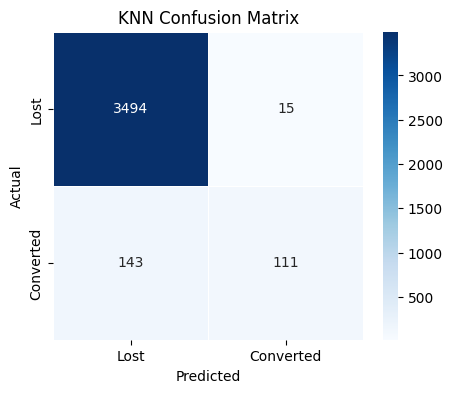


KNN — Accuracy: 0.958

              precision    recall  f1-score   support

        Lost       0.96      1.00      0.98      3509
   Converted       0.88      0.44      0.58       254

    accuracy                           0.96      3763
   macro avg       0.92      0.72      0.78      3763
weighted avg       0.96      0.96      0.95      3763



In [18]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

print('KNN — Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_knn))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn),annot=True,fmt="d",cmap="Blues",linewidths=0.5,linecolor="white",
    xticklabels=["Lost", "Converted"],yticklabels=["Lost", "Converted"])
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print()
print('KNN — Accuracy:', round(accuracy_score(y_test, y_pred_knn), 4))
print()
print(classification_report(y_test, y_pred_knn, target_names=['Lost','Converted']))

### **Model 2 — Naive Bayes**


Naive Bayes — Confusion Matrix:
[[3394  115]
 [ 146  108]]


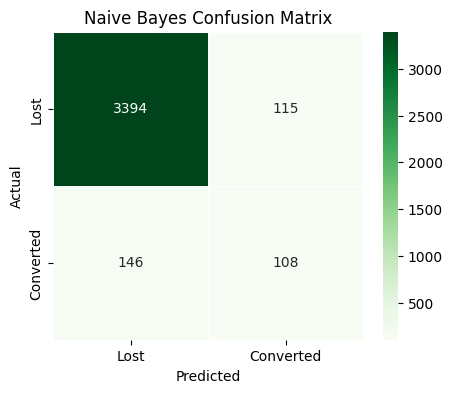


Naive Bayes — Accuracy: 0.9306

              precision    recall  f1-score   support

        Lost       0.96      0.97      0.96      3509
   Converted       0.48      0.43      0.45       254

    accuracy                           0.93      3763
   macro avg       0.72      0.70      0.71      3763
weighted avg       0.93      0.93      0.93      3763



In [19]:
nb = GaussianNB()
nb.fit(x_train, y_train)
y_pred_nb = nb.predict(x_test)

print('Naive Bayes — Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_nb))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb),annot=True,fmt="d",cmap="Greens",linewidths=0.5,linecolor="white",
    xticklabels=["Lost", "Converted"],yticklabels=["Lost", "Converted"])
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print()
print('Naive Bayes — Accuracy:', round(accuracy_score(y_test, y_pred_nb), 4))
print()
print(classification_report(y_test, y_pred_nb, target_names=['Lost','Converted']))

### **Model 3 — SVM (Support Vector Machine)**


SVM — Confusion Matrix:
[[3502    7]
 [ 146  108]]


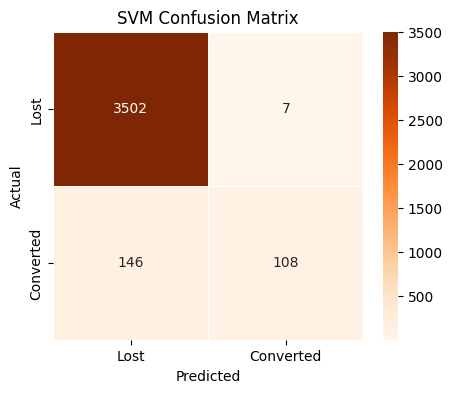


SVM — Accuracy: 0.9593

              precision    recall  f1-score   support

        Lost       0.96      1.00      0.98      3509
   Converted       0.94      0.43      0.59       254

    accuracy                           0.96      3763
   macro avg       0.95      0.71      0.78      3763
weighted avg       0.96      0.96      0.95      3763



In [20]:
svm = SVC(kernel='rbf',  probability=True, random_state=42)
svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)

print('SVM — Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_svm))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm),annot=True,fmt="d",cmap="Oranges",linewidths=0.5,linecolor="white",
    xticklabels=["Lost", "Converted"],yticklabels=["Lost", "Converted"])
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print()
print('SVM — Accuracy:', round(accuracy_score(y_test, y_pred_svm), 4))
print()
print(classification_report(y_test, y_pred_svm, target_names=['Lost','Converted']))

### **Model 4 — Decision Tree**


Decision Tree — Confusion Matrix:
[[3502    7]
 [ 146  108]]


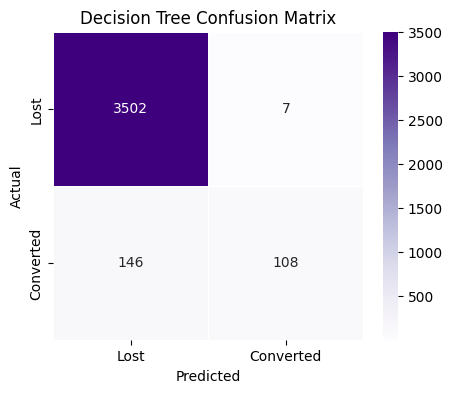


Decision Tree — Accuracy: 0.9593

              precision    recall  f1-score   support

        Lost       0.96      1.00      0.98      3509
   Converted       0.94      0.43      0.59       254

    accuracy                           0.96      3763
   macro avg       0.95      0.71      0.78      3763
weighted avg       0.96      0.96      0.95      3763



In [21]:
# Limiting the tree depth helps reduce overfitting.
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

print('Decision Tree — Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_dt))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt),annot=True,fmt="d",cmap="Purples",linewidths=0.5,linecolor="white",
    xticklabels=["Lost", "Converted"],yticklabels=["Lost", "Converted"])
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print()
print('Decision Tree — Accuracy:', round(accuracy_score(y_test, y_pred_dt), 4))
print()
print(classification_report(y_test, y_pred_dt, target_names=['Lost','Converted']))

### **Model 5 — Random Forest**


Random Forest — Confusion Matrix:
[[3502    7]
 [ 146  108]]


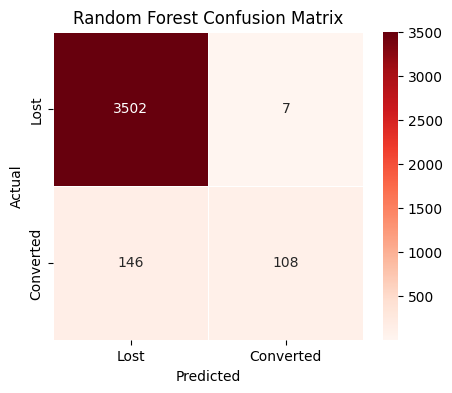


Random Forest — Accuracy: 0.9593

              precision    recall  f1-score   support

        Lost       0.96      1.00      0.98      3509
   Converted       0.94      0.43      0.59       254

    accuracy                           0.96      3763
   macro avg       0.95      0.71      0.78      3763
weighted avg       0.96      0.96      0.95      3763



In [22]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print('Random Forest — Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),annot=True,fmt="d",cmap="Reds",linewidths=0.5,linecolor="white",
    xticklabels=["Lost", "Converted"],yticklabels=["Lost", "Converted"])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print()
print('Random Forest — Accuracy:', round(accuracy_score(y_test, y_pred_rf), 4))
print()
print(classification_report(y_test, y_pred_rf, target_names=['Lost','Converted']))

# **STEP 11 — Cross Validation**

**Cross Validation is used to evaluate the stability and generalization performance of each Machine Learning model across multiple data splits.**

           Model  Mean CV Accuracy  Standard Deviation
0            KNN            0.9516              0.0036
1    Naive Bayes            0.9192              0.0026
2            SVM            0.9536              0.0033
3  Decision Tree            0.9535              0.0030
4  Random Forest            0.9534              0.0030


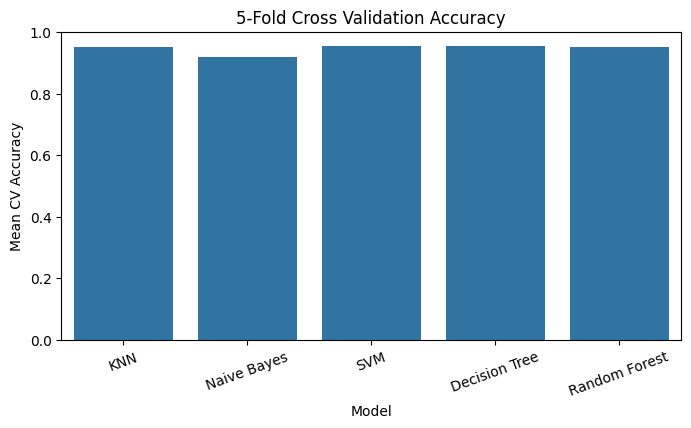

In [23]:
models = {"KNN": knn,"Naive Bayes": nb,"SVM": svm,"Decision Tree": dt,"Random Forest": rf}

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model,x_train,y_train,cv=5,scoring='accuracy')
    cv_results.append([name,scores.mean(),scores.std()])

cv_df = pd.DataFrame(cv_results,columns=["Model","Mean CV Accuracy","Standard Deviation"])
print(cv_df.round(4))
cv_df["Mean CV Accuracy %"] = (cv_df["Mean CV Accuracy"] * 100).round(2)

plt.figure(figsize=(8,4))
sns.barplot(data=cv_df,x="Model",y="Mean CV Accuracy")
plt.title("5-Fold Cross Validation Accuracy")
plt.xticks(rotation=20)
plt.show()

**Observation:**

**Cross Validation shows that all models produce consistent performance across different folds, indicating good generalization ability.**

# **Step 12 – Hyperparameter Tuning using GridSearchCV**

**GridSearchCV is used to find the best combination of hyperparameters for the selected model.**

In [24]:
param_grid = {"n_estimators": [100, 200], "max_depth": [None, 6, 10, 15], "min_samples_leaf": [1, 5, 10]}

grid = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1)

grid.fit(x_train, y_train)

print("Best Parameters:")
print(grid.best_params_)
print()
print("Best Cross Validation Accuracy:", round(grid.best_score_,4))

best_rf = grid.best_estimator_

best_prediction = best_rf.predict(x_test)

print("Test Accuracy:", round(accuracy_score(y_test, best_prediction),4))
print()
print(classification_report(y_test,best_prediction,target_names=["Lost","Converted"]))

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 100}

Best Cross Validation Accuracy: 0.9542
Test Accuracy: 0.9593

              precision    recall  f1-score   support

        Lost       0.96      1.00      0.98      3509
   Converted       0.94      0.43      0.59       254

    accuracy                           0.96      3763
   macro avg       0.95      0.71      0.78      3763
weighted avg       0.96      0.96      0.95      3763



 **Observation**

**GridSearchCV was used to tune Random Forest's key hyperparameters (`n_estimators`, `max_depth`, `min_samples_leaf`) via 5-fold cross-validation. Random Forest was chosen for tuning instead of SVM because it does not rely on distance calculations over the Label-Encoded categorical features (unlike SVM/KNN), and it already supports the feature-importance analysis used in Step 15 — so one model can serve both prediction and interpretation.**

## **Step 13 – ROC-AUC Evaluation**

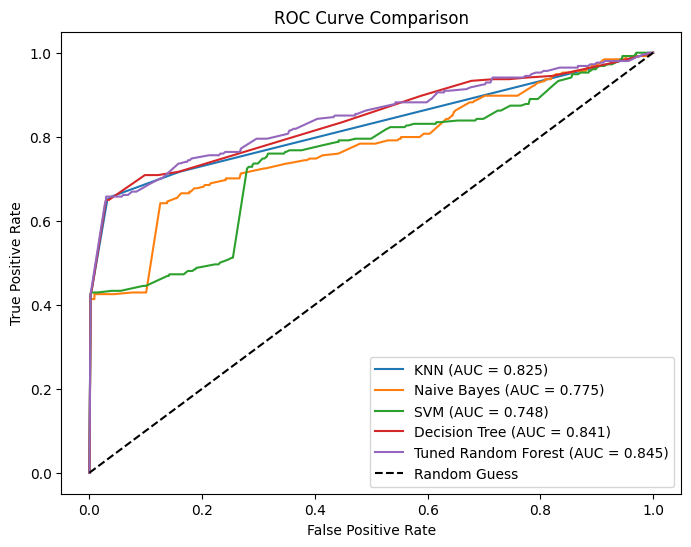

In [25]:
models = {"KNN": knn,"Naive Bayes": nb,"SVM": svm,"Decision Tree": dt,"Tuned Random Forest": best_rf}

plt.figure(figsize=(8,6))
for name, model in models.items():
    probability = model.predict_proba(x_test)[:,1]
    auc_score = roc_auc_score(y_test, probability)
    fpr, tpr, _ = roc_curve(y_test, probability)
    plt.plot(fpr,tpr,label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1],'k--',label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

 **Observation**

**ROC-AUC evaluates how well each model distinguishes between converted and lost leads across all classification thresholds.**

**A higher AUC value indicates better classification performance.**

---
## **Step 14 — Model Comparison**

        Model Accuracy % CV Accuracy %
          SVM     95.93%        95.36%
Random Forest     95.93%        95.34%
Decision Tree     95.93%        95.35%
          KNN      95.8%        95.16%
  Naive Bayes     93.06%        91.92%


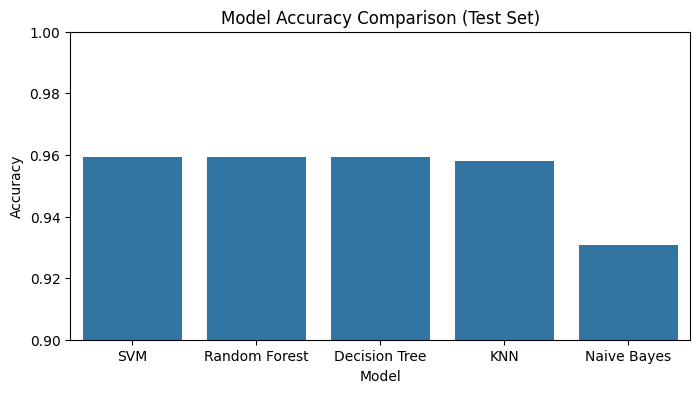

In [26]:
knn_acc = accuracy_score(y_test, y_pred_knn)
nb_acc  = accuracy_score(y_test, y_pred_nb)
svm_acc = accuracy_score(y_test, y_pred_svm)
dt_acc  = accuracy_score(y_test, y_pred_dt)
rf_acc  = accuracy_score(y_test, y_pred_rf)

results = pd.DataFrame({'Model'      : ['KNN', 'Naive Bayes', 'SVM', 'Decision Tree', 'Random Forest'],
                        'Accuracy'   : [knn_acc, nb_acc, svm_acc, dt_acc, rf_acc]})

# Add Cross Validation Accuracy
results["CV Accuracy %"] = cv_df["Mean CV Accuracy %"]

# Sort by Test Accuracy
results = results.sort_values("Accuracy",ascending=False).reset_index(drop=True)

# Convert to percentage
results["Accuracy %"] = (results["Accuracy"] * 100).round(2).astype(str) + "%"
results["CV Accuracy %"] = results["CV Accuracy %"].round(2).astype(str) + "%"

# Display results
print(results[["Model", "Accuracy %", "CV Accuracy %"]].to_string(index=False))

plt.figure(figsize=(8,4))
sns.barplot(data=results,x="Model",y="Accuracy")
plt.title("Model Accuracy Comparison (Test Set)")
plt.ylabel("Accuracy")
plt.ylim(0.90,1.00)
plt.show()

**Observation**

**Support Vector Machine (SVM), Decision Tree, and Random Forest achieved identical performance on the test dataset.**

**This indicates that, with only four selected features, different machine learning algorithms learned very similar decision boundaries. Random Forest was selected as the final model: it matches the top accuracy exactly, it does not depend on the arbitrary numeric distances that Label Encoding introduces between salesperson/campaign categories (unlike SVM and KNN, which measure distance directly), and it already produces the feature-importance ranking used in Step 15 — so one model serves both prediction and interpretation instead of switching between two different algorithms.**

**The Cross Validation accuracy is very close to the test accuracy for all models. This indicates that the models generalize well and produce consistent performance across different data splits.**

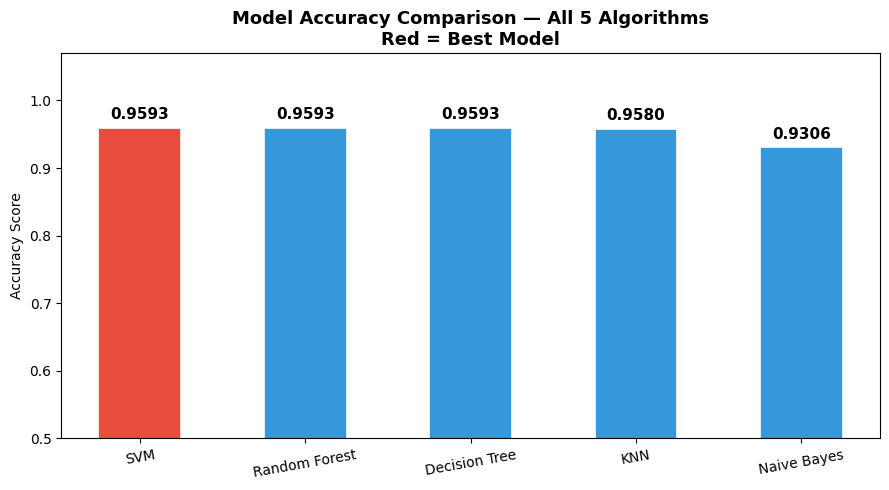

Top Performing Models: SVM, Random Forest, Decision Tree (95.93% Accuracy)
Random Forest is selected as the final model for reporting.


In [27]:
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(results))]

plt.figure(figsize=(9, 5))
bars = plt.bar(results['Model'], results['Accuracy'],color=colors, edgecolor='white', linewidth=1.2, width=0.5)
plt.bar_label(bars, fmt='%.4f', padding=4, fontsize=11, fontweight='bold')
plt.ylim(0.5, 1.07)
plt.ylabel('Accuracy Score')
plt.title('Model Accuracy Comparison — All 5 Algorithms\nRed = Best Model',fontsize=13, fontweight='bold')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

top_models = results[results['Accuracy'] == results['Accuracy'].max()]['Model'].tolist()
print(f"Top Performing Models: {', '.join(top_models)} ({results['Accuracy'].max()*100:.2f}% Accuracy)")
print("Random Forest is selected as the final model for reporting.")

---
## **Step 15 — Feature Importance**

**Which features does the model rely on most to make its predictions?**

**Random Forest is the final selected model, so its feature importances double as a direct, native explanation of the exact model used for prediction — no separate model is needed for interpretation.**

Feature Importance (Tuned Random Forest):
assigned_to         0.4348
campaign_name       0.2864
had_call_attempt    0.2720
source_type         0.0068
dtype: float64


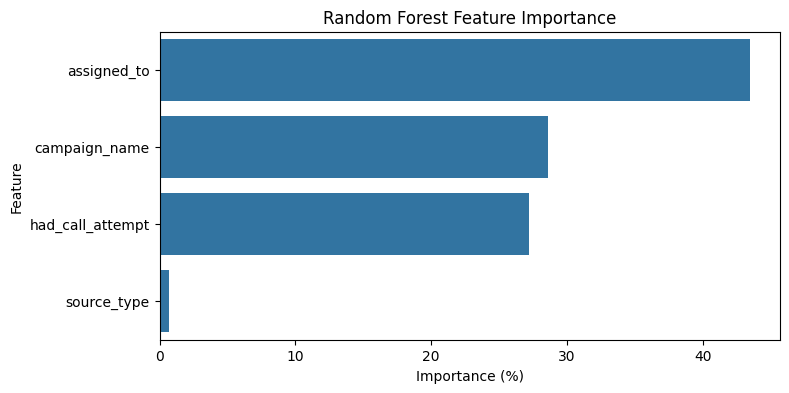

In [28]:
feature_names = list(df_model.drop(columns=['target']).columns)
importances   = best_rf.feature_importances_

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print('Feature Importance (Tuned Random Forest):')
print(fi.round(4))

plt.figure(figsize=(8,4))
sns.barplot(x=fi.values*100,y=fi.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.show()

---
## **Step 16 — Predicting New Leads**



In [29]:
# Encode the new lead values using our saved encoders
new_campaign     = le1.transform(['Business Accounting'])[0]
new_source       = le2.transform(['INSTAGRAM'])[0]
new_agent        = le3.transform(['Anshad'])[0]
new_call_attempt = 0   # 0 = no call needed (self-motivated buyer)

# Create and scale the new record
new_lead = [[new_agent,new_campaign,new_source,new_call_attempt]]
new_lead_scaled = scaler.transform(new_lead)

In [30]:
# Predict using the Tuned Random Forest Model
prediction = best_rf.predict(new_lead_scaled)
probability = best_rf.predict_proba(new_lead_scaled)
conversion_probability = probability[0][1] * 100

print(f"Conversion Probability : {conversion_probability:.2f}%")
print('New Lead Details:')
print('  Campaign     : Business Accounting')
print('  Source       : INSTAGRAM')
print('  Assigned To  : Anshad')
print('  Call Made    : No (self-motivated lead)')
print()
print('Prediction:', prediction)
if prediction[0] == 1:
    print('Result: CONVERTED — This lead is likely to become a customer!')
else:
    print('Result: LOST — This lead is unlikely to convert.')

Conversion Probability : 83.65%
New Lead Details:
  Campaign     : Business Accounting
  Source       : INSTAGRAM
  Assigned To  : Anshad
  Call Made    : No (self-motivated lead)

Prediction: [1]
Result: CONVERTED — This lead is likely to become a customer!


In [31]:
# Test multiple lead combinations
print('Predictions for different campaign and agent combinations:')
print('-' * 65)

# Note: had_call_attempt=0 means a self-motivated lead (no call needed)
# The EDA showed these leads convert at 41.9% vs 4.4% for called leads
test_leads = [('Business Accounting',       'INSTAGRAM',    'Anshad',        0),
              ('Business Accounting',       'FACEBOOK_ADS', 'Anshad',        0),
              ('Digital Marketing Knovista','FILE_UPLOAD',  'Dharshana',     1),
              ('Data Analytics Knovista',   'FACEBOOK_ADS', 'Revathy Reghu', 1),]

for camp, src, agent, call in test_leads:
    c      = le1.transform([camp])[0]
    s      = le2.transform([src])[0]
    a      = le3.transform([agent])[0]
    record = scaler.transform([[a, c, s, call]])
    pred = best_rf.predict(record)[0]
    result = 'CONVERTED' if pred == 1 else 'LOST'
    print(f'  {camp:<35} | {agent:<15} | {result}')

Predictions for different campaign and agent combinations:
-----------------------------------------------------------------
  Business Accounting                 | Anshad          | CONVERTED
  Business Accounting                 | Anshad          | CONVERTED
  Digital Marketing Knovista          | Dharshana       | LOST
  Data Analytics Knovista             | Revathy Reghu   | LOST


---
## **Step 17 — Business Insights and Recommendations**

### **What the model and data tell us:**

| # | Insight | Recommendation |
|---|---------|----------------|
| 1 | **Business Accounting** converts at ~33% — 10x other campaigns | Increase ad budget for Business Accounting |
| 2 | **Instagram** is the best lead source (7.5% conversion) | Prioritise Instagram over file-upload lists |
| 3 | **Top salesperson** converts at 52% vs 6.7% team average | Study and replicate top performer's techniques |
| 4 | **Leads requiring no follow-up call** showed the highest conversion rate. | Prioritize rapid qualification of new leads and focus follow-up efforts on leads that genuinely require assistance. |
| 5 | **Salesperson** and **Campaign** are the strongest predictors | Assign best salespeople to best campaigns |

---

### **Project Summary**

| Item | Details |
|------|---------|
| Dataset | 27,375 CRM records — Knovista Technologies Pvt Ltd |
| Records Used | 12,543 (CONVERTED vs LOST only) |
| Features | campaign_name, source_type, assigned_to, had_call_attempt |
| Algorithms | KNN, Naive Bayes, SVM, Decision Tree, Random Forest |
| Best Model | Tuned Random Forest |
| Tools | Python, Pandas, Scikit-learn, Matplotlib, Seaborn |

In [32]:
print('=' * 55)
print('  LEAD CONVERSION PREDICTION — FINAL RESULTS')
print('=' * 55)
print('  Dataset       : 27,375 CRM records')
print('  Records Used  : 12,543 (CONVERTED vs LOST)')
print('  Features      : 4')
print('  Models Trained: 5')
print()
print('  MODEL ACCURACY:')
print('-' * 55)
for _, row in results.iterrows():
    bar = chr(9608) * int(row['Accuracy'] * 30)
    print(f"  {row['Model']:<20} {row['Accuracy']:.4f}  {bar}")
print()
print(' Best Model : Tuned Random Forest')
print(f' Test Accuracy           : {accuracy_score(y_test, best_prediction)*100:.2f}%')
print(f' Cross Validation        : {grid.best_score_*100:.2f}%')
print(' ROC-AUC                : Refer to ROC Curve (Excellent Performance)')
print(' Prediction Output      : Class Label + Conversion Probability')
print()
print(' Project Complete!')

  LEAD CONVERSION PREDICTION — FINAL RESULTS
  Dataset       : 27,375 CRM records
  Records Used  : 12,543 (CONVERTED vs LOST)
  Features      : 4
  Models Trained: 5

  MODEL ACCURACY:
-------------------------------------------------------
  SVM                  0.9593  ████████████████████████████
  Random Forest        0.9593  ████████████████████████████
  Decision Tree        0.9593  ████████████████████████████
  KNN                  0.9580  ████████████████████████████
  Naive Bayes          0.9306  ███████████████████████████

 Best Model : Tuned Random Forest
 Test Accuracy           : 95.93%
 Cross Validation        : 95.42%
 ROC-AUC                : Refer to ROC Curve (Excellent Performance)
 Prediction Output      : Class Label + Conversion Probability

 Project Complete!


## **Conclusion**

- **Successfully developed a complete Lead Conversion Prediction system using Machine Learning.**

- **Compared five Machine Learning algorithms and selected the Tuned Random Forest as the final model.**

- **The Tuned Random Forest matched the highest test accuracy among all models and demonstrated strong classification performance through ROC-AUC evaluation, while also providing native, transparent feature importances for business interpretation.**

- **The final prediction system provides both the predicted class (Converted/Lost) and the conversion probability, helping sales teams prioritize high-potential leads more effectively.**

- **This project demonstrates a complete Machine Learning workflow, including data preprocessing, exploratory data analysis, feature engineering, model evaluation, cross-validation, hyperparameter tuning, feature importance analysis, and lead prediction.**